# 16: End-to-End Causal Discovery Case Study

This lesson pulls the tutorial pieces together into a complete causal discovery workflow. Instead of focusing on one algorithm, we will walk through the full lifecycle of an applied discovery analysis: problem framing, data dictionary, data audit, domain constraints, candidate graph estimation, stability checks, final graph selection, and report-ready limitations.

The case study is synthetic and company-neutral. We simulate a small product-engagement dataset where the true graph is known for learning. In a real project, the true graph would not be available, so the same workflow would rely more heavily on domain review, stability checks, and follow-up validation.

Estimated runtime: about 2-4 minutes. The lesson runs PC, GES, DirectLiNGAM, FCI, and several bootstrap checks on a small dataset.


## Learning Goals

By the end, you should be able to:

- turn a vague discovery question into a concrete graph target;
- document variables, timing, and domain constraints before running algorithms;
- audit a discovery dataset for missingness, scale, dependence, and suspicious structure;
- compare candidate graphs from PC, GES, and DirectLiNGAM;
- use background knowledge to orient edges that time order already rules out;
- summarize edge consensus and bootstrap stability;
- produce a final candidate graph with appropriate caveats.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **End-To-End Causal Discovery Case Study**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment is closer to a complete applied analysis. Question framing, design, estimation, diagnostics, and reporting are meant to be read together.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Causal discovery produces an estimated graph $\widehat G$. A compact benchmark compares it with a reference graph $G$ through structural Hamming distance,

$$
\operatorname{SHD}(\widehat G,G)=\text{edge additions}+\text{edge deletions}+\text{edge reversals}.
$$

Stability can be summarized by a bootstrap edge frequency,

$$
\widehat\pi_{ij}=\frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\{i\rightarrow j\in\widehat G_b\}.
$$

The reporting goal is to show which edges are stable, which assumptions matter, and which conclusions remain tentative.



The workflow follows the order a careful discovery project should use:

1. Define the case-study question and variable dictionary.
2. Simulate a example dataset and save the synthetic truth.
3. Audit the observed data before discovery.
4. Encode domain timing constraints.
5. Run candidate discovery algorithms.
6. Compare graphs to synthetic truth and to each other.
7. Check tuning and bootstrap stability.
8. Use FCI as a hidden-confounding screen.
9. Assemble a final candidate graph and report-ready edge table.
10. Save outputs and limitations.


## Case-Study Question

Suppose a product analytics team wants to understand the causal structure behind a simple engagement funnel. They have observational measurements of user need, catalog fit, onboarding friction, discovery quality, early engagement, support contact, and retention value.

The discovery question is:

**Which measured factors appear to be direct causes of downstream engagement and retention outcomes, after accounting for the rest of the observed system?**

This is a graph-discovery question, not an effect-estimation question. The output is a candidate causal graph that can guide later experiments, quasi-experimental studies, or targeted causal effect estimation.





## Tutorial Workflow

### Why This is End-to-End

An end-to-end discovery workflow is more than an algorithm call. The algorithm is one component inside a larger discipline:

- define the time order and forbidden directions before looking at graph output;
- inspect the data-generating plausibility of algorithm assumptions;
- compare several method families rather than trusting one graph;
- check edge stability across reasonable perturbations;
- label final edges by evidence strength rather than pretending every edge is equally supported.

That full workflow is what this lesson demonstrates.


#### Setup

The code below imports the scientific Python stack, causal-learn algorithms, and graph drawing utilities. It also sets up output folders and silences known lesson-environment warnings.


In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import time
import warnings
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "causal_learn":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "causal_learn" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"
for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="Using 'local_score_BIC_from_cov' instead for efficiency")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
import causallearn.search.ScoreBased.GES as ges_module
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.FCMBased.lingam.direct_lingam import DirectLiNGAM
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
NOTEBOOK_PREFIX = "16"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})
print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")


Project root: repository root
Outputs: notebooks/tutorials/causal_learn/outputs


The output folder is shared with the rest of the causal-learn tutorial series. Every output created here starts with `16_`.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Package Versions

Saving package versions is part of reproducible graph discovery. Small numerical and graph-format differences can matter when comparing discovered structures.


In [2]:
import causallearn
import sklearn
version_table = pd.DataFrame(
    [
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "causal-learn", "version": getattr(causallearn, "__version__", "not exposed")},
    ]
)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)


,package,version
0,numpy,2.4.4
1,pandas,3.0.2
2,scikit-learn,1.6.1
3,causal-learn,not exposed


The version table is now saved. This is useful when a graph needs to be reproduced or compared with another run later.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### GES BIC Compatibility Wrapper

The GES BIC score needs a small local compatibility wrapper in this environment. The wrapper keeps the same BIC scoring logic while safely converting one-element matrix results into Python scalars.


In [3]:
def local_score_BIC_from_cov(Data, i, PAi, parameters=None):
    """
    Safe local BIC score used by GES in this lesson.
    
    Parameters
    ----------
    Data : array-like
        Data matrix passed by causal-learn into the local score function.
    i : int
        Target variable index for the local score calculation.
    PAi : list[int]
        Parent indices proposed for the target variable in the local score.
    parameters : dict
        Score-function parameters supplied by causal-learn.
    
    Returns
    -------
    float
        BIC-style local score for one target variable and candidate parent set.
    """
    cov, n = Data
    lambda_value = 0.5 if parameters is None or parameters.get("lambda_value") is None else parameters.get("lambda_value")
    parent_indices = list(PAi)
    if len(parent_indices) == 0:
        residual_variance = cov[i, i]
    else:
        yX = cov[np.ix_([i], parent_indices)]
        XX = cov[np.ix_(parent_indices, parent_indices)]
        beta = np.linalg.solve(XX, yX.T)
        residual_variance = cov[i, i] - float((yX @ beta).item())
    residual_variance = max(float(residual_variance), 1e-12)
    return float(-(n / 2) * np.log(residual_variance) - (len(parent_indices) + 1) * lambda_value * np.log(n) / 2)
ges_module.local_score_BIC_from_cov = local_score_BIC_from_cov
print("GES BIC score wrapper is active for this lesson session.")


GES BIC score wrapper is active for this lesson session.


The wrapper only affects this lesson session. It does not edit `causal-learn` on disk.

For the discovery workflow, this result should be read as evidence about graph recovery under the stated assumptions.
<!-- result-implication-expanded -->


#### Data Dictionary

The case study uses seven measured variables. The timing column captures a rough process order. This timing information becomes background knowledge later, because later outcomes should not cause earlier setup variables.


In [4]:
VARIABLES = [
    "baseline_need",
    "catalog_fit",
    "onboarding_friction",
    "discovery_quality",
    "early_engagement",
    "support_contact",
    "retention_value",
]
VAR_INDEX = {name: i for i, name in enumerate(VARIABLES)}
DISPLAY_LABELS = {
    "baseline_need": "baseline\nneed",
    "catalog_fit": "catalog\nfit",
    "onboarding_friction": "onboarding\nfriction",
    "discovery_quality": "discovery\nquality",
    "early_engagement": "early\nengagement",
    "support_contact": "support\ncontact",
    "retention_value": "retention\nvalue",
}
variable_dictionary = pd.DataFrame(
    [
        {
            "variable": "baseline_need",
            "plain_language_meaning": "Pre-existing user need or motivation before the experience starts.",
            "timing_tier": 0,
            "role": "upstream context",
        },
        {
            "variable": "catalog_fit",
            "plain_language_meaning": "How well available items fit the user's likely interests.",
            "timing_tier": 1,
            "role": "upstream context",
        },
        {
            "variable": "onboarding_friction",
            "plain_language_meaning": "Early confusion, setup cost, or friction before meaningful use.",
            "timing_tier": 2,
            "role": "early barrier",
        },
        {
            "variable": "discovery_quality",
            "plain_language_meaning": "Quality of the initial discovery or recommendation experience.",
            "timing_tier": 3,
            "role": "candidate mechanism",
        },
        {
            "variable": "early_engagement",
            "plain_language_meaning": "Depth of initial usage after discovery.",
            "timing_tier": 4,
            "role": "intermediate outcome",
        },
        {
            "variable": "support_contact",
            "plain_language_meaning": "Whether the user needed help or support after early use.",
            "timing_tier": 5,
            "role": "friction outcome",
        },
        {
            "variable": "retention_value",
            "plain_language_meaning": "Downstream user value or retention signal.",
            "timing_tier": 6,
            "role": "final outcome",
        },
    ]
)
variable_dictionary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_variable_dictionary.csv", index=False)
display(variable_dictionary)


,variable,plain_language_meaning,timing_tier,role
0,baseline_need,Pre-existing user need or motivation before the experience starts.,0,upstream context
1,catalog_fit,How well available items fit the user's likely interests.,1,upstream context
2,onboarding_friction,"Early confusion, setup cost, or friction before meaningful use.",2,early barrier
3,discovery_quality,Quality of the initial discovery or recommendation experience.,3,candidate mechanism
4,early_engagement,Depth of initial usage after discovery.,4,intermediate outcome
5,support_contact,Whether the user needed help or support after early use.,5,friction outcome
6,retention_value,Downstream user value or retention signal.,6,final outcome


The tier order does not prove causality. It only encodes directions that are impossible or implausible given the measurement process.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


### Synthetic Truth for Teaching

Because this is a tutorial, we simulate the dataset from a known graph. In a real case study, this table would not exist; it is included here so we can evaluate how the workflow behaves.


In [5]:
TRUE_EDGES = [
    ("baseline_need", "discovery_quality"),
    ("catalog_fit", "discovery_quality"),
    ("onboarding_friction", "early_engagement"),
    ("onboarding_friction", "support_contact"),
    ("discovery_quality", "early_engagement"),
    ("discovery_quality", "retention_value"),
    ("early_engagement", "retention_value"),
    ("support_contact", "retention_value"),
]
true_edge_table = pd.DataFrame(TRUE_EDGES, columns=["source", "target"])
true_edge_table.insert(0, "run", "truth")
true_edge_table["edge_type"] = "-->"
true_edge_table = true_edge_table[["run", "source", "edge_type", "target"]]
true_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_edges.csv", index=False)
display(true_edge_table)


,run,source,edge_type,target
0,truth,baseline_need,-->,discovery_quality
1,truth,catalog_fit,-->,discovery_quality
2,truth,onboarding_friction,-->,early_engagement
3,truth,onboarding_friction,-->,support_contact
4,truth,discovery_quality,-->,early_engagement
5,truth,discovery_quality,-->,retention_value
6,truth,early_engagement,-->,retention_value
7,truth,support_contact,-->,retention_value


The true graph is kept sparse enough to read. That keeps the case study readable while still including multiple parents, downstream mediation, and a support-related pathway.


#### Simulate the Case-Study Dataset

The simulator generates a clean observational dataset from the true graph. The noise is non-Gaussian so DirectLiNGAM has a fair chance to orient edges, while PC and GES still have useful structure to recover.


In [6]:
# Define reusable helpers for the Simulate The Case-Study Dataset section.
def simulate_case_study_data(n_samples=900, seed=RANDOM_SEED, noise_scale=0.80, hidden_strength=0.0):
    """
    Simulate the end-to-end case-study dataset.
    
    Parameters
    ----------
    n_samples : int
        Number of observations generated, sampled, or evaluated.
    seed : int
        Random seed for reproducible simulation or resampling.
    noise_scale : object
        Noise scale used to control signal-to-noise difficulty in the simulation.
    hidden_strength : object
        Strength of the hidden confounder injected into the simulation.
    
    Returns
    -------
    pd.DataFrame
        Case-study dataset with observed variables and optional hidden-confounding strength.
    """
    rng = np.random.default_rng(seed)
    hidden_context = rng.laplace(loc=0.0, scale=1.0, size=n_samples)
    baseline_need = rng.laplace(loc=0.0, scale=1.0, size=n_samples) + hidden_strength * hidden_context
    catalog_fit = rng.laplace(loc=0.0, scale=1.0, size=n_samples)
    onboarding_friction = rng.laplace(loc=0.0, scale=1.0, size=n_samples)
    discovery_quality = (
        0.70 * baseline_need
        + 0.80 * catalog_fit
        + rng.laplace(loc=0.0, scale=noise_scale, size=n_samples)
    )
    early_engagement = (
        0.80 * discovery_quality
        - 0.55 * onboarding_friction
        + rng.laplace(loc=0.0, scale=noise_scale, size=n_samples)
    )
    support_contact = (
        0.70 * onboarding_friction
        + rng.laplace(loc=0.0, scale=noise_scale, size=n_samples)
    )
    retention_value = (
        0.30 * discovery_quality
        + 0.65 * early_engagement
        - 0.55 * support_contact
        + rng.laplace(loc=0.0, scale=noise_scale, size=n_samples)
        + hidden_strength * hidden_context
    )
    raw_df = pd.DataFrame(
        {
            "baseline_need": baseline_need,
            "catalog_fit": catalog_fit,
            "onboarding_friction": onboarding_friction,
            "discovery_quality": discovery_quality,
            "early_engagement": early_engagement,
            "support_contact": support_contact,
            "retention_value": retention_value,
        }
    )
    scaled_df = pd.DataFrame(StandardScaler().fit_transform(raw_df), columns=VARIABLES)
    return scaled_df
case_df = simulate_case_study_data()
case_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_case_study_observed_data.csv", index=False)
display(case_df.head())
print(f"Dataset shape: {case_df.shape}")


,baseline_need,catalog_fit,onboarding_friction,discovery_quality,early_engagement,support_contact,retention_value
0,-0.103157,0.167717,0.337250,-0.174835,-1.521579,0.505952,-1.408331
1,-0.523238,0.192072,0.064646,-0.718328,-0.563849,-0.395677,-0.361103
2,-1.766077,-0.932466,-0.151183,-1.474795,-0.890423,-0.203887,-0.784043
3,-0.083583,0.337327,0.676568,-0.175165,-0.405918,-0.143214,-0.618329
4,1.727252,0.295308,0.383671,1.974841,0.797577,0.359012,0.997640


Dataset shape: (900, 7)


The saved dataset contains only observed variables. The hidden-context option is reserved for a later stress check and is not present in the baseline case-study data.





## Diagnostics and Interpretation

### Data Audit: Shape, Missingness, and Scale

Before discovery, we check the basics: missing values, variance, and range. A graph search can look sophisticated while quietly failing because of ordinary data quality problems.


In [7]:
data_audit = pd.DataFrame(
    {
        "mean": case_df.mean(),
        "std": case_df.std(),
        "min": case_df.min(),
        "max": case_df.max(),
        "missing_rate": case_df.isna().mean(),
        "unique_values": case_df.nunique(),
    }
).reset_index(names="variable")
data_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_data_audit.csv", index=False)
display(data_audit.round(3))


,variable,mean,std,min,max,missing_rate,unique_values
0,baseline_need,0.0,1.001,-4.942,4.751,0.0,900
1,catalog_fit,-0.0,1.001,-4.796,5.404,0.0,900
2,onboarding_friction,-0.0,1.001,-4.448,4.542,0.0,900
3,discovery_quality,-0.0,1.001,-3.288,3.896,0.0,900
4,early_engagement,0.0,1.001,-2.940,4.630,0.0,900
5,support_contact,-0.0,1.001,-4.542,3.886,0.0,900
6,retention_value,-0.0,1.001,-3.051,3.431,0.0,900


The audit is clean: no missing values, no constant columns, and standardized scales. That lets the rest of the lesson focus on graph assumptions rather than preprocessing repairs.


### Data Audit: Correlations

Correlation cannot identify causality. It is still a useful diagnostic. It helps reveal whether the simulated data contain the expected dependence structure before we run graph algorithms.


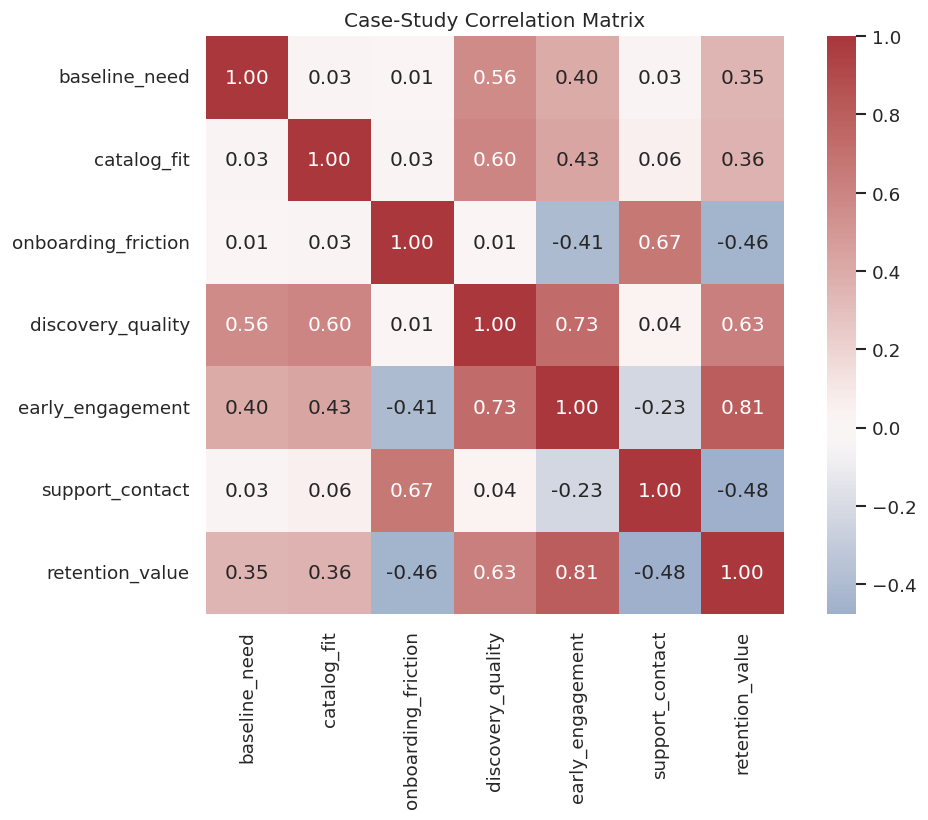

In [8]:
correlation_matrix = case_df.corr()
correlation_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Case-Study Correlation Matrix")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


The correlations show plausible relationships along the funnel, especially around discovery quality, engagement, and retention value. The graph search will now ask which of those associations look direct after conditioning on other variables.


### Data Audit: Distribution Shape

Some algorithms rely on distributional clues. DirectLiNGAM, for example, is designed for linear non-Gaussian data. The next step shows marginal distributions for all variables.


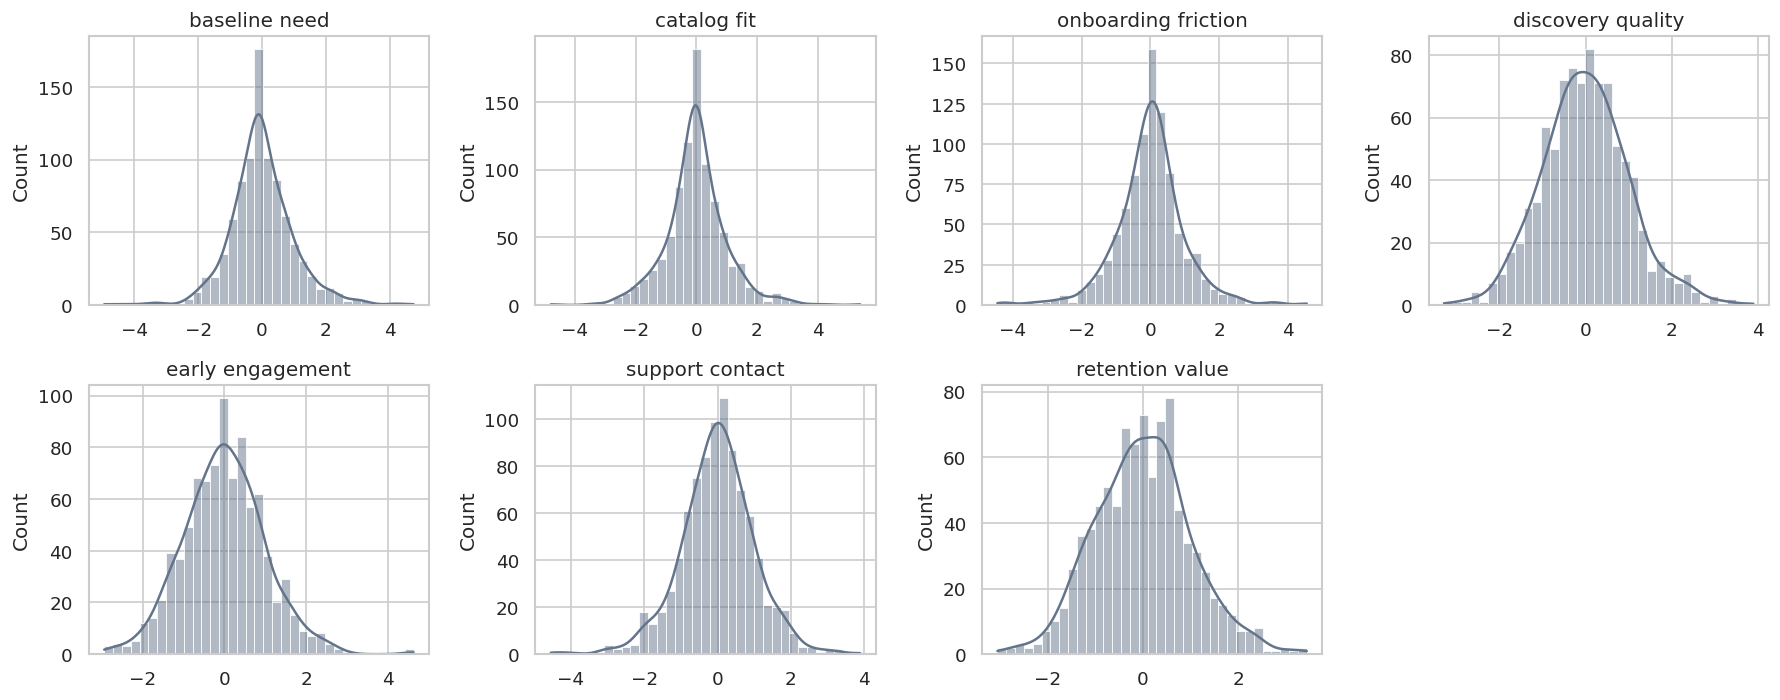

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()
for ax, variable in zip(axes, VARIABLES):
    sns.histplot(case_df[variable], bins=35, kde=True, color="#64748b", ax=ax)
    ax.set_title(DISPLAY_LABELS[variable].replace("\n", " "))
    ax.set_xlabel("")
for ax in axes[len(VARIABLES):]:
    ax.set_axis_off()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_marginal_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The variables are not perfectly Gaussian, which makes DirectLiNGAM a reasonable candidate method. This is still only a diagnostic, not a guarantee that LiNGAM assumptions are fully true.




#### Draw the Teaching Truth

This graph is the synthetic answer key. In a real end-to-end analysis, this figure would be replaced by a domain hypothesis diagram rather than known truth.


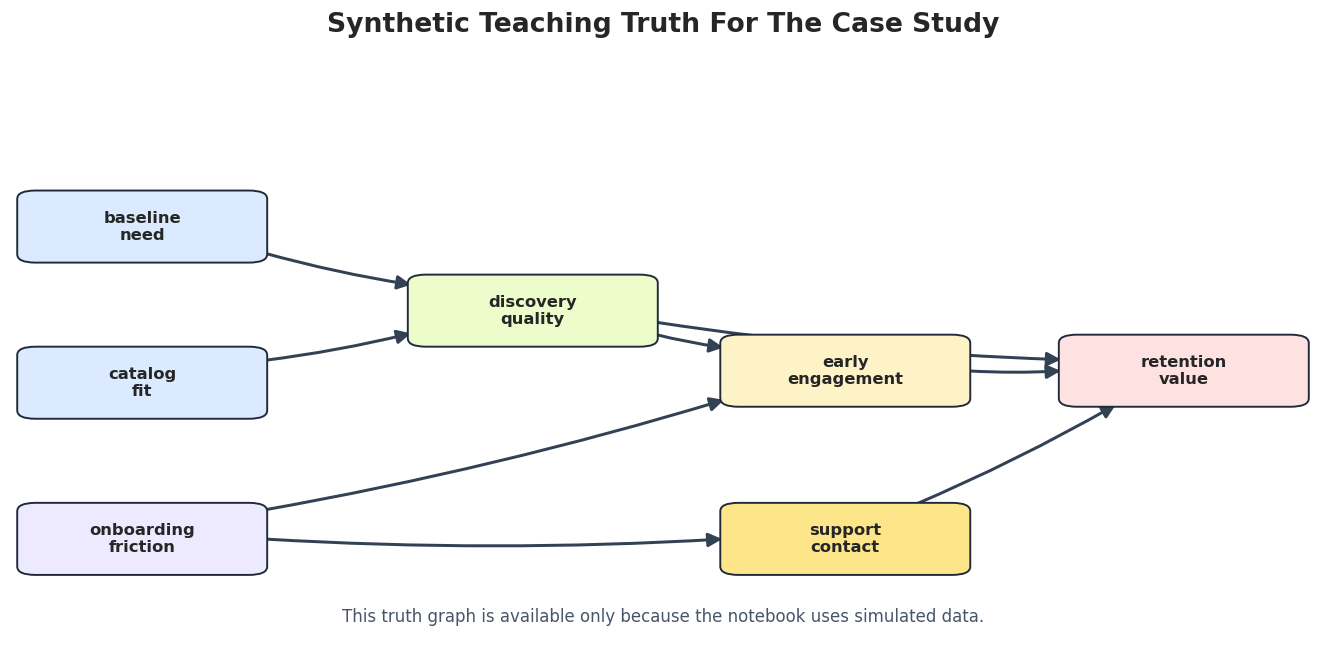

In [10]:
# Define reusable helpers for the Draw The Teaching Truth section.
def trim_edge_to_box(start, end, box_w=0.16, box_h=0.09, gap=0.012):
    """
    Idea: Trim an arrow segment so graph edges stop at the border of each plotted node.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    box_w : object
        Width of the plotted node box.
    box_h : object
        Height of the plotted node box.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]]
        Start and end coordinates trimmed so the edge stops at box boundaries.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    distance = (dx**2 + dy**2) ** 0.5
    if distance == 0:
        return start, end
    ux, uy = dx / distance, dy / distance
    candidates = []
    if abs(ux) > 1e-9:
        candidates.append((box_w / 2) / abs(ux))
    if abs(uy) > 1e-9:
        candidates.append((box_h / 2) / abs(uy))
    offset = min(candidates) + gap
    return (x0 + ux * offset, y0 + uy * offset), (x1 - ux * offset, y1 - uy * offset)
GRAPH_POSITIONS = {
    "baseline_need": (0.10, 0.72),
    "catalog_fit": (0.10, 0.46),
    "onboarding_friction": (0.10, 0.20),
    "discovery_quality": (0.40, 0.58),
    "early_engagement": (0.64, 0.48),
    "support_contact": (0.64, 0.20),
    "retention_value": (0.90, 0.48),
}
GRAPH_COLORS = {
    "baseline_need": "#dbeafe",
    "catalog_fit": "#dbeafe",
    "onboarding_friction": "#ede9fe",
    "discovery_quality": "#ecfccb",
    "early_engagement": "#fef3c7",
    "support_contact": "#fde68a",
    "retention_value": "#fee2e2",
}
def draw_box_graph(edge_df, title, path, note=None, highlight_edges=None):
    """
    Idea: Render a small graph from an edge table using boxed nodes and visible arrows.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    title : str
        Title shown on the resulting plot or report.
    path : str or pathlib.Path
        Input or output path.
    note : object
        Short annotation shown below or beside the plotted figure.
    highlight_edges : pd.DataFrame or collection
        Edges associated with `highlight`.
    
    Returns
    -------
    None
        Draws the graph diagram directly on the Matplotlib axes and saves it when requested.
    """
    highlight_edges = highlight_edges or set()
    fig, ax = plt.subplots(figsize=(14, 6.5))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    for row in edge_df.itertuples(index=False):
        if row.source not in GRAPH_POSITIONS or row.target not in GRAPH_POSITIONS:
            continue
        start, end = trim_edge_to_box(GRAPH_POSITIONS[row.source], GRAPH_POSITIONS[row.target])
        edge_key = (row.source, row.target)
        edge_type = row.edge_type
        color = "#7c3aed" if edge_key in highlight_edges else "#334155"
        arrowstyle = "-|>" if edge_type == "-->" else "-"
        linewidth = 2.4 if edge_key in highlight_edges else 1.8
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=17,
            linewidth=linewidth,
            color=color,
            connectionstyle="arc3,rad=0.03",
            zorder=2,
        )
        ax.add_patch(arrow)
    for variable, (x, y) in GRAPH_POSITIONS.items():
        rect = FancyBboxPatch(
            (x - 0.082, y - 0.046),
            0.164,
            0.092,
            boxstyle="round,pad=0.014",
            facecolor=GRAPH_COLORS[variable],
            edgecolor="#1f2937",
            linewidth=1.15,
            zorder=4,
        )
        ax.add_patch(rect)
        ax.text(x, y, DISPLAY_LABELS[variable], ha="center", va="center", fontsize=9.8, fontweight="bold", zorder=5)
    if note:
        ax.text(0.5, 0.07, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=16, fontsize=16, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
draw_box_graph(
    true_edge_table,
    "Synthetic Teaching Truth For The Case Study",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_case_study_graph.png",
    note="This truth graph is available only because the notebook uses simulated data.",
)


The truth graph gives us a way to score the workflow. In real work, the same visual style can be used for a pre-analysis domain graph and for the final candidate graph.


#### Encode Domain Timing Constraints

The variable dictionary gave each variable a timing tier. The next step converts that tier order into `causal-learn` background knowledge for PC: later variables are not allowed to cause earlier variables.


In [11]:
def build_tier_background_knowledge(variable_dictionary):
    """
    Idea: Build the tier background knowledge representation used by the Encode Domain Timing Constraints analysis.
    
    Parameters
    ----------
    variable_dictionary : object
        Table describing the variables available in the synthetic discovery data.
    
    Returns
    -------
    BackgroundKnowledge
        causal-learn background-knowledge object with variables assigned to their timing tiers.
    """
    nodes = {variable: GraphNode(variable) for variable in variable_dictionary["variable"]}
    knowledge = BackgroundKnowledge()
    for row in variable_dictionary.itertuples(index=False):
        knowledge.add_node_to_tier(nodes[row.variable], int(row.timing_tier))
    return knowledge
background_knowledge = build_tier_background_knowledge(variable_dictionary)
constraint_table = variable_dictionary[["variable", "timing_tier", "role"]].copy()
constraint_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_timing_constraints.csv", index=False)
display(constraint_table)


,variable,timing_tier,role
0,baseline_need,0,upstream context
1,catalog_fit,1,upstream context
2,onboarding_friction,2,early barrier
3,discovery_quality,3,candidate mechanism
4,early_engagement,4,intermediate outcome
5,support_contact,5,friction outcome
6,retention_value,6,final outcome


The constraints are modest but important. They do not force any edge to exist; they only rule out time-reversing directions.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### Graph Parsing and Evaluation Helpers

This helper block converts outputs from causal-learn into one standard edge table format and computes skeleton and direction metrics against the synthetic truth.


In [12]:
# Define reusable helpers for the Graph Parsing And Evaluation Helpers section.
def parse_causallearn_edge(edge):
    """
    Idea: Convert a causal-learn graph edge object into plain endpoint labels for tabular auditing.
    
    Parameters
    ----------
    edge : object
        Single graph edge being parsed, drawn, or evaluated.
    
    Returns
    -------
    tuple[str, str, str]
        Source node, endpoint mark, and target node parsed from a causal-learn edge.
    """
    text = str(edge).strip()
    edge_tokens = [" --> ", " <-- ", " <-> ", " o-> ", " <-o ", " o-o ", " --- "]
    for token in edge_tokens:
        if token in text:
            left, right = text.split(token)
            if token == " <-- ":
                return {"source": right.strip(), "edge_type": "-->", "target": left.strip()}
            if token == " <-o ":
                return {"source": right.strip(), "edge_type": "o->", "target": left.strip()}
            return {"source": left.strip(), "edge_type": token.strip(), "target": right.strip()}
    raise ValueError(f"Could not parse edge: {text}")
def graph_to_edge_table(graph, label):
    """
    Idea: Convert a causal-learn graph object into a DataFrame of edge endpoints and method labels.
    
    Parameters
    ----------
    graph : object
        Graph object returned by the causal discovery or causal modeling library.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        Edge table with source, target, edge mark, and method metadata.
    """
    rows = [parse_causallearn_edge(edge) for edge in graph.get_graph_edges()]
    edge_table = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    edge_table.insert(0, "run", label)
    return edge_table
def lingam_to_edge_table(adjacency_matrix, label, threshold=0.12):
    """
    Idea: Convert a LiNGAM adjacency matrix into a directed edge table using a coefficient threshold.
    
    Parameters
    ----------
    adjacency_matrix : np.ndarray
        Matrix whose nonzero entries represent candidate directed edges.
    label : str
        Short label attached to a scenario, method, or plotted result.
    threshold : float
        Cutoff used to decide whether a signal or edge is retained.
    
    Returns
    -------
    pd.DataFrame
        Directed edge table from LiNGAM coefficients above the threshold.
    """
    rows = []
    for target in VARIABLES:
        for source in VARIABLES:
            if source == target:
                continue
            coefficient = float(adjacency_matrix[VAR_INDEX[target], VAR_INDEX[source]])
            if abs(coefficient) >= threshold:
                rows.append(
                    {
                        "run": label,
                        "source": source,
                        "edge_type": "-->",
                        "target": target,
                        "coefficient": coefficient,
                        "abs_coefficient": abs(coefficient),
                    }
                )
    return pd.DataFrame(rows, columns=["run", "source", "edge_type", "target", "coefficient", "abs_coefficient"])
def skeleton_pairs(edge_df):
    """
    Idea: Reduce an edge table to unordered node pairs so skeleton recovery can be evaluated.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    
    Returns
    -------
    set[tuple[str, str]]
        Unordered node pairs representing the learned graph skeleton.
    """
    if edge_df.empty:
        return set()
    return {tuple(sorted((row.source, row.target))) for row in edge_df.itertuples(index=False)}
def directed_pairs(edge_df):
    """
    Idea: Extract directed edge pairs from an edge table so orientation recovery can be evaluated.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    
    Returns
    -------
    set[tuple[str, str]]
        Ordered source-target pairs representing directed learned edges.
    """
    if edge_df.empty:
        return set()
    return {(row.source, row.target) for row in edge_df.itertuples(index=False) if row.edge_type == "-->"}
TRUE_DIRECTED = set(TRUE_EDGES)
TRUE_SKELETON = {tuple(sorted(edge)) for edge in TRUE_EDGES}
def summarize_against_truth(edge_df, label, scenario="case_study"):
    """
    Idea: Summarize the against truth into a compact table for interpretation in the Graph Parsing And Evaluation Helpers section.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Graph edges or edge-level diagnostics to summarize.
    label : str
        Short label attached to a scenario, method, or plotted result.
    scenario : str
        Scenario label describing the data-generating or diagnostic condition.
    
    Returns
    -------
    pd.DataFrame
        Graph-recovery summary table with edge counts, precision, recall, missing edges, and extra edges.
    """
    learned_skeleton = skeleton_pairs(edge_df)
    learned_directed = directed_pairs(edge_df)
    skeleton_tp = learned_skeleton & TRUE_SKELETON
    skeleton_fp = learned_skeleton - TRUE_SKELETON
    skeleton_fn = TRUE_SKELETON - learned_skeleton
    directed_tp = learned_directed & TRUE_DIRECTED
    directed_fp = learned_directed - TRUE_DIRECTED
    directed_fn = TRUE_DIRECTED - learned_directed
    reversed_true_edges = {(target, source) for source, target in learned_directed} & TRUE_DIRECTED
    skeleton_precision = len(skeleton_tp) / len(learned_skeleton) if learned_skeleton else np.nan
    skeleton_recall = len(skeleton_tp) / len(TRUE_SKELETON)
    skeleton_f1 = 2 * skeleton_precision * skeleton_recall / (skeleton_precision + skeleton_recall) if skeleton_precision + skeleton_recall > 0 else np.nan
    directed_precision = len(directed_tp) / len(learned_directed) if learned_directed else np.nan
    directed_recall = len(directed_tp) / len(TRUE_DIRECTED)
    directed_f1 = 2 * directed_precision * directed_recall / (directed_precision + directed_recall) if directed_precision + directed_recall > 0 else np.nan
    return pd.DataFrame(
        [
            {
                "scenario": scenario,
                "method": label,
                "reported_edges": len(edge_df),
                "skeleton_precision": skeleton_precision,
                "skeleton_recall": skeleton_recall,
                "skeleton_f1": skeleton_f1,
                "directed_precision": directed_precision,
                "directed_recall": directed_recall,
                "directed_f1": directed_f1,
                "extra_adjacencies": len(skeleton_fp),
                "missed_adjacencies": len(skeleton_fn),
                "reversed_true_edges": len(reversed_true_edges),
                "missed_adjacency_list": " | ".join(f"{a}--{b}" for a, b in sorted(skeleton_fn)),
                "extra_adjacency_list": " | ".join(f"{a}--{b}" for a, b in sorted(skeleton_fp)),
            }
        ]
    )


The metrics keep adjacency recovery and arrow recovery separate. That distinction is especially important for PC and GES, which can return partially directed graphs.


#### Algorithm Runners

The case study compares four views:

- unconstrained PC, to see what the data alone suggest;
- tier-constrained PC, to respect domain timing;
- GES, a score-based candidate graph;
- DirectLiNGAM, a linear non-Gaussian directed graph.


In [13]:
# Define reusable helpers for the Algorithm Runners section.
def run_pc_case(data_df, alpha=0.01, label="PC_unconstrained", background_knowledge=None):
    """
    Idea: Run PC for one case-study scenario and package the graph-recovery output.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    alpha : float
        Significance level, transparency value, or tuning parameter used by the diagnostic.
    label : str
        Short label attached to a scenario, method, or plotted result.
    background_knowledge : object
        Prior graph restrictions supplied to the discovery algorithm.
    
    Returns
    -------
    pd.DataFrame
        PC case-study edge table with scenario labels.
    """
    start = time.perf_counter()
    result = pc(
        data_df.to_numpy(),
        alpha=alpha,
        indep_test="fisherz",
        stable=True,
        show_progress=False,
        node_names=VARIABLES,
        background_knowledge=background_knowledge,
    )
    elapsed = time.perf_counter() - start
    return graph_to_edge_table(result.G, label), elapsed
def run_ges_case(data_df, lambda_value=1.0, label="GES_BIC"):
    """
    Idea: Run GES for one case-study scenario and package the graph-recovery output.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    lambda_value : float
        Penalty value used by score-based search or a learner.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        GES case-study edge table with scenario labels.
    """
    start = time.perf_counter()
    values = data_df.to_numpy()
    record = ges(
        score_func="local_score_BIC_from_cov",
        cov=np.cov(values.T, ddof=0),
        n=len(data_df),
        node_names=VARIABLES,
        parameters={"lambda_value": lambda_value},
    )
    elapsed = time.perf_counter() - start
    return graph_to_edge_table(record["G"], label), elapsed
def run_direct_lingam_case(data_df, threshold=0.12, label="DirectLiNGAM"):
    """
    Idea: Run DirectLiNGAM for one case-study scenario and package the graph-recovery output.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    threshold : float
        Cutoff used to decide whether a signal or edge is retained.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        DirectLiNGAM case-study edge table with scenario labels.
    """
    start = time.perf_counter()
    model = DirectLiNGAM(random_state=RANDOM_SEED)
    model.fit(data_df.to_numpy())
    elapsed = time.perf_counter() - start
    return lingam_to_edge_table(model.adjacency_matrix_, label=label, threshold=threshold), elapsed, model
def run_fci_case(data_df, alpha=0.01, label="FCI_FisherZ"):
    """
    Idea: Run FCI for one case-study scenario and package the graph-recovery output.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Rows for the current simulated or observed experiment.
    alpha : float
        Significance level, transparency value, or tuning parameter used by the diagnostic.
    label : str
        Short label attached to a scenario, method, or plotted result.
    
    Returns
    -------
    pd.DataFrame
        FCI case-study edge table with scenario labels.
    """
    start = time.perf_counter()
    graph, _ = fci(
        data_df.to_numpy(),
        independence_test_method="fisherz",
        alpha=alpha,
        show_progress=False,
        node_names=VARIABLES,
    )
    elapsed = time.perf_counter() - start
    return graph_to_edge_table(graph, label), elapsed


The runner functions keep tuning choices explicit. This makes later sensitivity checks easier to read.


#### Run Candidate Discovery Methods

We now estimate candidate graphs. The unconstrained PC graph is useful as a diagnostic, but the constrained PC graph better respects the known timing order.


In [14]:
candidate_results = []
candidate_edges = []
pc_unconstrained_edges, pc_unconstrained_elapsed = run_pc_case(case_df, alpha=0.01, label="PC_unconstrained")
candidate_results.append(summarize_against_truth(pc_unconstrained_edges, "PC_unconstrained").assign(elapsed_seconds=pc_unconstrained_elapsed))
candidate_edges.append(pc_unconstrained_edges.assign(elapsed_seconds=pc_unconstrained_elapsed))
pc_tier_edges, pc_tier_elapsed = run_pc_case(case_df, alpha=0.01, label="PC_tier_constrained", background_knowledge=background_knowledge)
candidate_results.append(summarize_against_truth(pc_tier_edges, "PC_tier_constrained").assign(elapsed_seconds=pc_tier_elapsed))
candidate_edges.append(pc_tier_edges.assign(elapsed_seconds=pc_tier_elapsed))
ges_edges, ges_elapsed = run_ges_case(case_df, lambda_value=1.0, label="GES_BIC")
candidate_results.append(summarize_against_truth(ges_edges, "GES_BIC").assign(elapsed_seconds=ges_elapsed))
candidate_edges.append(ges_edges.assign(elapsed_seconds=ges_elapsed))
lingam_edges, lingam_elapsed, lingam_model = run_direct_lingam_case(case_df, threshold=0.12, label="DirectLiNGAM")
candidate_results.append(summarize_against_truth(lingam_edges, "DirectLiNGAM").assign(elapsed_seconds=lingam_elapsed))
candidate_edges.append(lingam_edges.assign(elapsed_seconds=lingam_elapsed))
candidate_metrics = pd.concat(candidate_results, ignore_index=True)
candidate_edge_table = pd.concat(candidate_edges, ignore_index=True)
candidate_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_candidate_method_metrics.csv", index=False)
candidate_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_candidate_method_edges.csv", index=False)
display(candidate_metrics.round(4))
display(candidate_edge_table)


,scenario,method,reported_edges,skeleton_precision,skeleton_recall,skeleton_f1,directed_precision,directed_recall,directed_f1,extra_adjacencies,missed_adjacencies,reversed_true_edges,missed_adjacency_list,extra_adjacency_list,elapsed_seconds
0,case_study,PC_unconstrained,7,0.8571,0.75,0.8,0.7143,0.625,0.6667,1,2,1,discovery_quality--retention_value | early_engagement--onboarding_friction,onboarding_friction--retention_value,0.0119
1,case_study,PC_tier_constrained,7,0.8571,0.75,0.8,0.8571,0.750,0.8000,1,2,0,discovery_quality--retention_value | early_engagement--onboarding_friction,onboarding_friction--retention_value,0.0119
2,case_study,GES_BIC,8,1.0000,1.00,1.0,1.0000,0.875,0.9333,0,0,0,,,0.0206
3,case_study,DirectLiNGAM,8,1.0000,1.00,1.0,1.0000,1.000,1.0000,0,0,0,,,0.0373


,run,source,edge_type,target,elapsed_seconds,coefficient,abs_coefficient
0,PC_unconstrained,baseline_need,-->,discovery_quality,0.011930,NaN,NaN
1,PC_unconstrained,catalog_fit,-->,discovery_quality,0.011930,NaN,NaN
2,PC_unconstrained,support_contact,-->,onboarding_friction,0.011930,NaN,NaN
3,PC_unconstrained,retention_value,-->,onboarding_friction,0.011930,NaN,NaN
4,PC_unconstrained,discovery_quality,-->,early_engagement,0.011930,NaN,NaN
5,PC_unconstrained,early_engagement,-->,retention_value,0.011930,NaN,NaN
6,PC_unconstrained,support_contact,-->,retention_value,0.011930,NaN,NaN
7,PC_tier_constrained,baseline_need,-->,discovery_quality,0.011855,NaN,NaN
8,PC_tier_constrained,catalog_fit,-->,discovery_quality,0.011855,NaN,NaN
9,PC_tier_constrained,onboarding_friction,-->,support_contact,0.011855,NaN,NaN


The candidate comparison shows the value of method triangulation. The constrained PC graph respects timing, GES provides a score-based view, and DirectLiNGAM gives a directed weighted view under non-Gaussian assumptions.




#### Plot Candidate Method Metrics

This plot compares skeleton and directed F1 for the candidate methods. The synthetic truth lets us quantify what would normally be judged through stability and domain review.


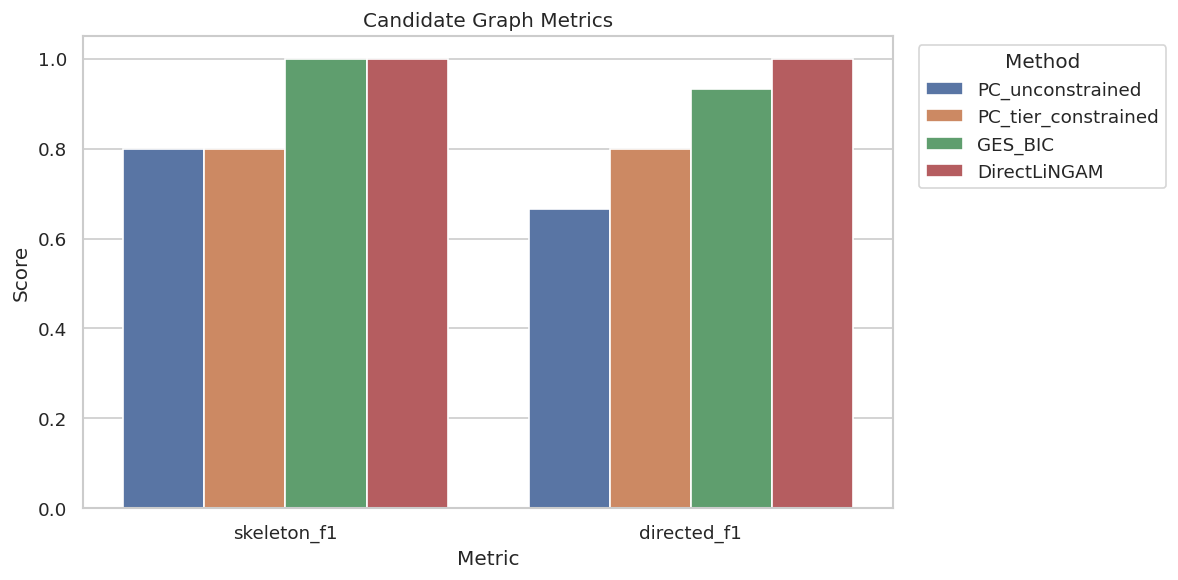

In [15]:
metric_plot = candidate_metrics.melt(
    id_vars="method",
    value_vars=["skeleton_f1", "directed_f1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metric_plot, x="metric", y="score", hue="method", ax=ax)
ax.set_title("Candidate Graph Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_candidate_method_metrics.png", dpi=160, bbox_inches="tight")
plt.show()


The plot highlights a common applied pattern: a method can recover a strong skeleton while leaving some arrows unresolved, and a functional method can recover more directions when its assumptions are plausible.




#### Draw Candidate Graphs

A table is precise, but graph drawings are better for stakeholder review. The next step saves the constrained PC, GES, and DirectLiNGAM candidate graphs.


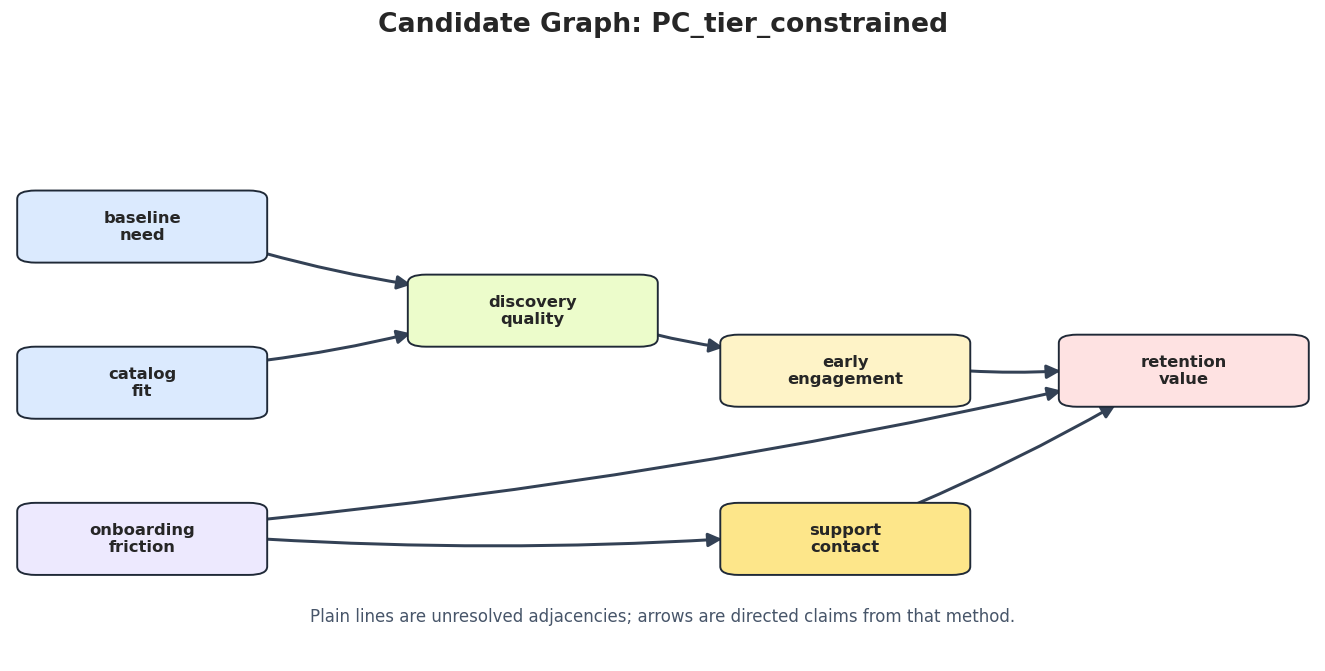

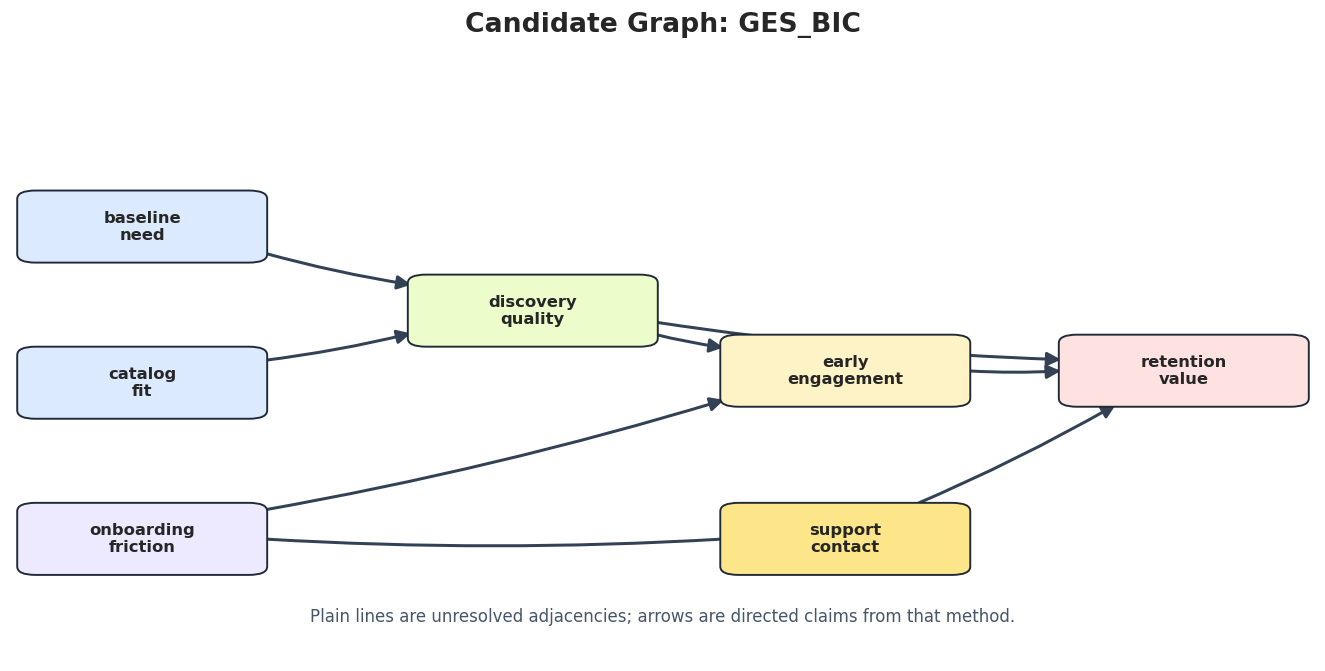

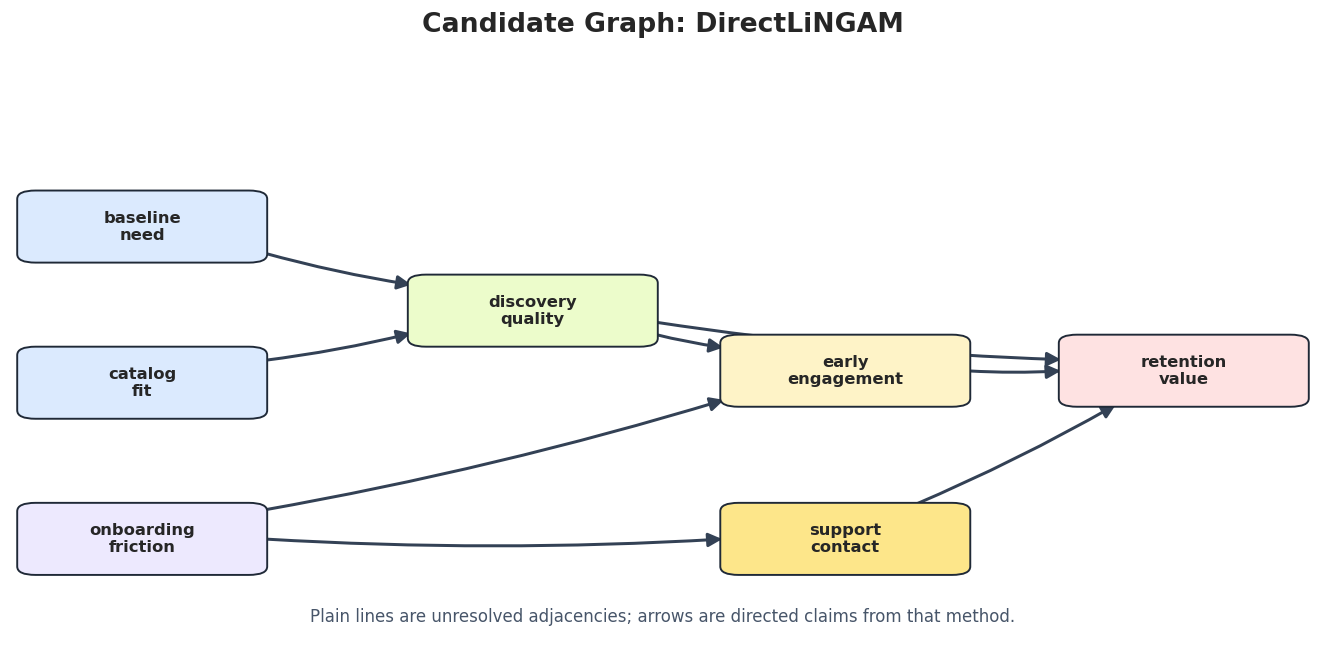

In [16]:
for method_name in ["PC_tier_constrained", "GES_BIC", "DirectLiNGAM"]:
    method_edges = candidate_edge_table[candidate_edge_table["run"] == method_name].copy()
    draw_box_graph(
        method_edges,
        f"Candidate Graph: {method_name}",
        FIGURE_DIR / f"{NOTEBOOK_PREFIX}_{method_name.lower()}_candidate_graph.png",
        note="Plain lines are unresolved adjacencies; arrows are directed claims from that method.",
    )


The candidate graphs make it easier to inspect where algorithms agree and where they disagree. This is the visual input to the consensus step.


#### Edge Consensus Across Methods

The next table counts how many candidate methods support each directed edge and each adjacency. We use only the three serious candidates for final review: tier-constrained PC, GES, and DirectLiNGAM.


In [17]:
review_methods = ["PC_tier_constrained", "GES_BIC", "DirectLiNGAM"]
review_edges = candidate_edge_table[candidate_edge_table["run"].isin(review_methods)].copy()
consensus_rows = []
for source in VARIABLES:
    for target in VARIABLES:
        if source == target:
            continue
        skeleton_key = tuple(sorted((source, target)))
        directed_support_methods = sorted(
            review_edges[
                (review_edges["source"] == source)
                & (review_edges["target"] == target)
                & (review_edges["edge_type"] == "-->")
            ]["run"].unique()
        )
        adjacency_support_methods = sorted(
            review_edges[
                review_edges.apply(lambda row: tuple(sorted((row["source"], row["target"]))) == skeleton_key, axis=1)
            ]["run"].unique()
        )
        if directed_support_methods or adjacency_support_methods:
            consensus_rows.append(
                {
                    "source": source,
                    "target": target,
                    "directed_support_count": len(directed_support_methods),
                    "adjacency_support_count": len(adjacency_support_methods),
                    "directed_support_methods": ", ".join(directed_support_methods),
                    "adjacency_support_methods": ", ".join(adjacency_support_methods),
                    "is_true_edge_in_synthetic_data": (source, target) in TRUE_DIRECTED,
                }
            )
edge_consensus = pd.DataFrame(consensus_rows).sort_values(
    ["directed_support_count", "adjacency_support_count", "source", "target"],
    ascending=[False, False, True, True],
)
edge_consensus.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_edge_consensus.csv", index=False)
display(edge_consensus)


,source,target,directed_support_count,adjacency_support_count,directed_support_methods,adjacency_support_methods,is_true_edge_in_synthetic_data
0,baseline_need,discovery_quality,3,3,"DirectLiNGAM, GES_BIC, PC_tier_constrained","DirectLiNGAM, GES_BIC, PC_tier_constrained",True
1,catalog_fit,discovery_quality,3,3,"DirectLiNGAM, GES_BIC, PC_tier_constrained","DirectLiNGAM, GES_BIC, PC_tier_constrained",True
7,discovery_quality,early_engagement,3,3,"DirectLiNGAM, GES_BIC, PC_tier_constrained","DirectLiNGAM, GES_BIC, PC_tier_constrained",True
11,early_engagement,retention_value,3,3,"DirectLiNGAM, GES_BIC, PC_tier_constrained","DirectLiNGAM, GES_BIC, PC_tier_constrained",True
13,support_contact,retention_value,3,3,"DirectLiNGAM, GES_BIC, PC_tier_constrained","DirectLiNGAM, GES_BIC, PC_tier_constrained",True
3,onboarding_friction,support_contact,2,3,"DirectLiNGAM, PC_tier_constrained","DirectLiNGAM, GES_BIC, PC_tier_constrained",True
8,discovery_quality,retention_value,2,2,"DirectLiNGAM, GES_BIC","DirectLiNGAM, GES_BIC",True
2,onboarding_friction,early_engagement,2,2,"DirectLiNGAM, GES_BIC","DirectLiNGAM, GES_BIC",True
4,onboarding_friction,retention_value,1,1,PC_tier_constrained,PC_tier_constrained,False
5,discovery_quality,baseline_need,0,3,,"DirectLiNGAM, GES_BIC, PC_tier_constrained",False


The consensus table gives a practical review queue. Edges supported by multiple methods and consistent with timing constraints are better candidates for the final graph.




#### Tuning Sensitivity

Before choosing a final graph, we scan key tuning knobs: PC alpha, GES BIC penalty, and DirectLiNGAM coefficient threshold.


In [18]:
tuning_rows = []
for alpha in [0.001, 0.005, 0.01, 0.05, 0.10]:
    edges, elapsed = run_pc_case(case_df, alpha=alpha, label="PC_tier_constrained", background_knowledge=background_knowledge)
    metrics = summarize_against_truth(edges, "PC_tier_constrained", scenario=f"pc_alpha_{alpha}")
    metrics["tuning_family"] = "PC alpha"
    metrics["tuning_value"] = alpha
    metrics["elapsed_seconds"] = elapsed
    tuning_rows.append(metrics)
for lambda_value in [0.50, 0.75, 1.00, 1.50, 2.00]:
    edges, elapsed = run_ges_case(case_df, lambda_value=lambda_value, label="GES_BIC")
    metrics = summarize_against_truth(edges, "GES_BIC", scenario=f"ges_lambda_{lambda_value}")
    metrics["tuning_family"] = "GES lambda"
    metrics["tuning_value"] = lambda_value
    metrics["elapsed_seconds"] = elapsed
    tuning_rows.append(metrics)
for threshold in [0.05, 0.08, 0.12, 0.16, 0.20]:
    edges = lingam_to_edge_table(lingam_model.adjacency_matrix_, label="DirectLiNGAM", threshold=threshold)
    metrics = summarize_against_truth(edges, "DirectLiNGAM", scenario=f"lingam_threshold_{threshold}")
    metrics["tuning_family"] = "LiNGAM threshold"
    metrics["tuning_value"] = threshold
    metrics["elapsed_seconds"] = 0.0
    tuning_rows.append(metrics)
tuning_sensitivity = pd.concat(tuning_rows, ignore_index=True)
tuning_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_tuning_sensitivity.csv", index=False)
display(tuning_sensitivity[["method", "tuning_family", "tuning_value", "reported_edges", "skeleton_f1", "directed_f1", "extra_adjacencies", "missed_adjacencies"]].round(4))


,method,tuning_family,tuning_value,reported_edges,skeleton_f1,directed_f1,extra_adjacencies,missed_adjacencies
0,PC_tier_constrained,PC alpha,0.001,7,0.8000,0.8000,1,2
1,PC_tier_constrained,PC alpha,0.005,7,0.8000,0.8000,1,2
2,PC_tier_constrained,PC alpha,0.010,7,0.8000,0.8000,1,2
3,PC_tier_constrained,PC alpha,0.050,8,1.0000,1.0000,0,0
4,PC_tier_constrained,PC alpha,0.100,8,1.0000,1.0000,0,0
5,GES_BIC,GES lambda,0.500,9,0.9412,0.9333,1,0
6,GES_BIC,GES lambda,0.750,8,1.0000,0.9333,0,0
7,GES_BIC,GES lambda,1.000,8,1.0000,0.9333,0,0
8,GES_BIC,GES lambda,1.500,8,1.0000,0.9333,0,0
9,GES_BIC,GES lambda,2.000,8,1.0000,0.9333,0,0


The tuning scan checks whether the candidate graph depends on a single arbitrary setting. Stable regions are more useful than isolated peaks.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Plot Tuning Sensitivity

The figure uses separate panels because each method has a different tuning parameter.


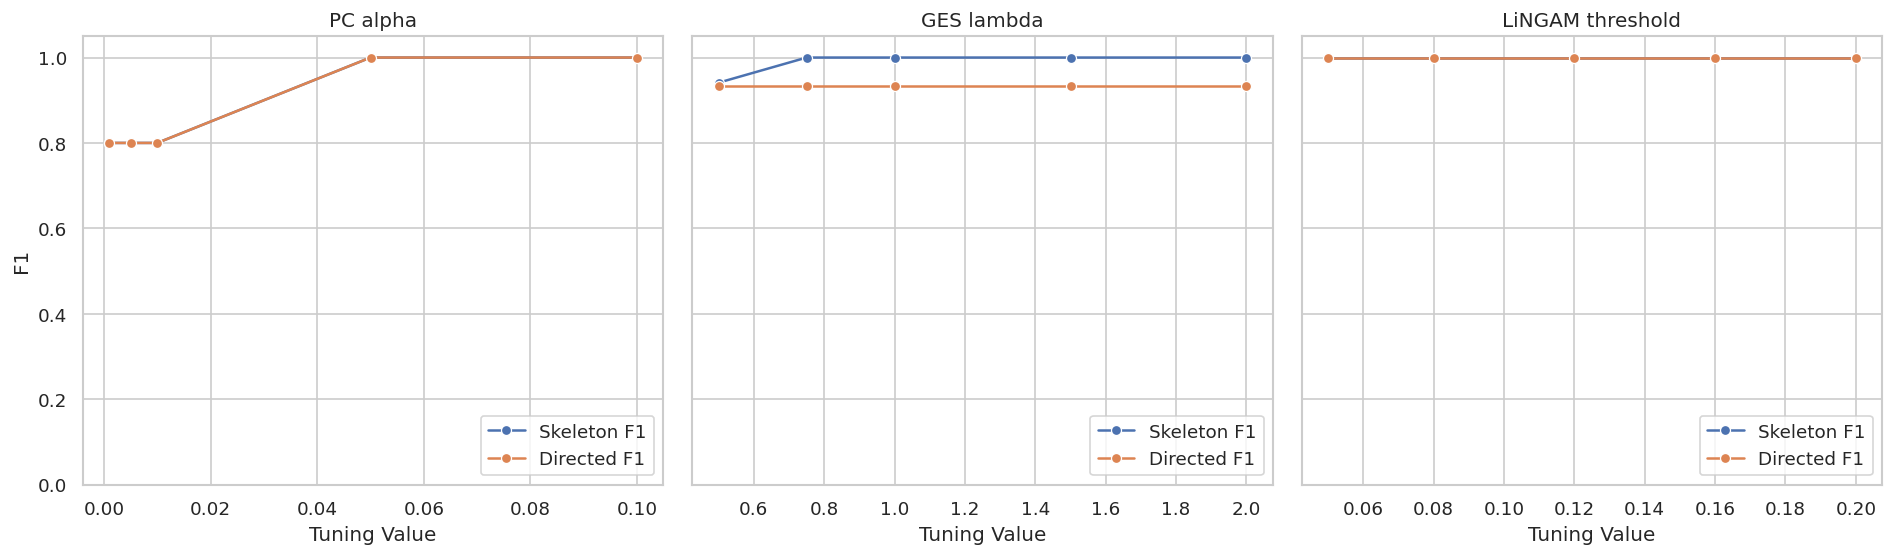

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, family in zip(axes, ["PC alpha", "GES lambda", "LiNGAM threshold"]):
    subset = tuning_sensitivity[tuning_sensitivity["tuning_family"] == family]
    sns.lineplot(data=subset, x="tuning_value", y="skeleton_f1", marker="o", label="Skeleton F1", ax=ax)
    sns.lineplot(data=subset, x="tuning_value", y="directed_f1", marker="o", label="Directed F1", ax=ax)
    ax.set_title(family)
    ax.set_xlabel("Tuning Value")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_tuning_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The plot helps decide whether the final graph is a robust finding or a fragile output of one tuning choice.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Bootstrap Edge Stability

A final graph should not depend on a single sample draw. We bootstrap rows, rerun the three candidate methods, and count how often each directed edge appears.


In [20]:
bootstrap_rows = []
bootstrap_edge_rows = []
bootstrap_rng = np.random.default_rng(RANDOM_SEED)
for bootstrap_id in range(20):
    sample_indices = bootstrap_rng.choice(case_df.index.to_numpy(), size=len(case_df), replace=True)
    sample_df = case_df.loc[sample_indices].reset_index(drop=True)
    method_outputs = []
    edges, elapsed = run_pc_case(sample_df, alpha=0.01, label="PC_tier_constrained", background_knowledge=background_knowledge)
    method_outputs.append(("PC_tier_constrained", edges, elapsed))
    edges, elapsed = run_ges_case(sample_df, lambda_value=1.0, label="GES_BIC")
    method_outputs.append(("GES_BIC", edges, elapsed))
    edges, elapsed, _ = run_direct_lingam_case(sample_df, threshold=0.12, label="DirectLiNGAM")
    method_outputs.append(("DirectLiNGAM", edges, elapsed))
    for method_name, edges, elapsed in method_outputs:
        metrics = summarize_against_truth(edges, method_name, scenario=f"bootstrap_{bootstrap_id}")
        metrics["bootstrap_id"] = bootstrap_id
        metrics["elapsed_seconds"] = elapsed
        bootstrap_rows.append(metrics)
        bootstrap_edge_rows.append(edges.assign(method=method_name, bootstrap_id=bootstrap_id, elapsed_seconds=elapsed))
bootstrap_metrics = pd.concat(bootstrap_rows, ignore_index=True)
bootstrap_edges = pd.concat(bootstrap_edge_rows, ignore_index=True)
bootstrap_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_metrics.csv", index=False)
bootstrap_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_edges.csv", index=False)
display(bootstrap_metrics.groupby("method", as_index=False).agg(
    runs=("bootstrap_id", "count"),
    mean_skeleton_f1=("skeleton_f1", "mean"),
    mean_directed_f1=("directed_f1", "mean"),
    min_directed_f1=("directed_f1", "min"),
).round(4))


,method,runs,mean_skeleton_f1,mean_directed_f1,min_directed_f1
0,DirectLiNGAM,20,0.9971,0.9971,0.9412
1,GES_BIC,20,0.9598,0.9067,0.5882
2,PC_tier_constrained,20,0.8824,0.8824,0.7500


The bootstrap summary gives a stability view by method. Next we turn the bootstrap edges into edge-level inclusion rates.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Edge-Level Stability Table

This table reports how often each directed edge appears across all method-bootstrap runs. It also records method-specific support so final graph selection can distinguish broad support from one-method support.


In [21]:
directed_bootstrap_edges = bootstrap_edges[bootstrap_edges["edge_type"] == "-->"].copy()
edge_stability_rows = []
for source in VARIABLES:
    for target in VARIABLES:
        if source == target:
            continue
        edge_subset = directed_bootstrap_edges[(directed_bootstrap_edges["source"] == source) & (directed_bootstrap_edges["target"] == target)]
        if edge_subset.empty:
            continue
        method_rates = edge_subset.groupby("method")["bootstrap_id"].nunique() / 20
        edge_stability_rows.append(
            {
                "source": source,
                "target": target,
                "overall_inclusion_rate": edge_subset[["method", "bootstrap_id"]].drop_duplicates().shape[0] / (20 * 3),
                "pc_rate": method_rates.get("PC_tier_constrained", 0.0),
                "ges_rate": method_rates.get("GES_BIC", 0.0),
                "lingam_rate": method_rates.get("DirectLiNGAM", 0.0),
                "methods_with_any_support": int((method_rates > 0).sum()),
                "is_true_edge_in_synthetic_data": (source, target) in TRUE_DIRECTED,
            }
        )
edge_stability = pd.DataFrame(edge_stability_rows).sort_values(
    ["overall_inclusion_rate", "methods_with_any_support", "source", "target"],
    ascending=[False, False, True, True],
)
edge_stability.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_edge_stability.csv", index=False)
display(edge_stability.round(3))


,source,target,overall_inclusion_rate,pc_rate,ges_rate,lingam_rate,methods_with_any_support,is_true_edge_in_synthetic_data
11,discovery_quality,early_engagement,1.000,1.00,1.00,1.00,3,True
14,early_engagement,retention_value,1.000,1.00,1.00,1.00,3,True
17,support_contact,retention_value,1.000,1.00,1.00,1.00,3,True
0,baseline_need,discovery_quality,0.983,1.00,0.95,1.00,3,True
4,catalog_fit,discovery_quality,0.983,1.00,0.95,1.00,3,True
6,onboarding_friction,early_engagement,0.867,0.60,1.00,1.00,3,True
12,discovery_quality,retention_value,0.750,0.25,1.00,1.00,3,True
7,onboarding_friction,support_contact,0.750,1.00,0.25,1.00,3,True
8,onboarding_friction,retention_value,0.200,0.55,0.05,0.00,2,False
13,early_engagement,support_contact,0.100,0.10,0.20,0.00,2,False


The stability table is the main evidence table for final graph selection. Edges with high inclusion across multiple method families are easier to defend.


#### Plot Edge Stability

The plot shows the strongest directed edges by overall inclusion rate.


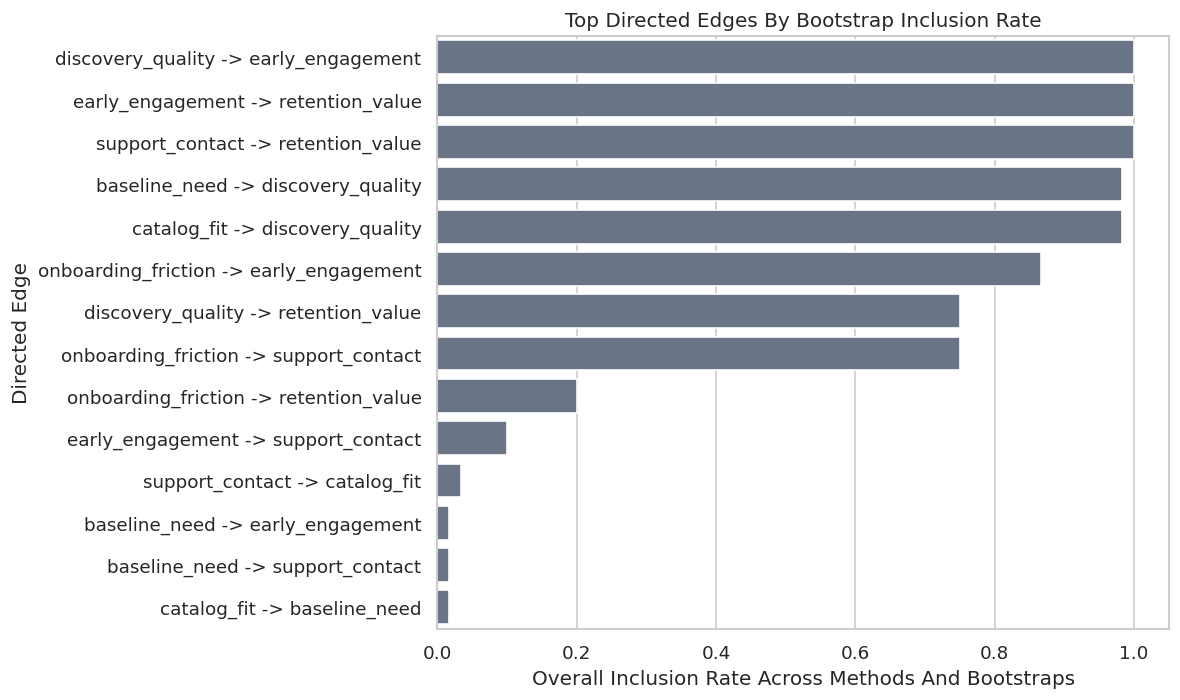

In [22]:
stability_plot = edge_stability.head(14).copy()
stability_plot["edge"] = stability_plot["source"] + " -> " + stability_plot["target"]
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=stability_plot, y="edge", x="overall_inclusion_rate", color="#64748b", ax=ax)
ax.set_title("Top Directed Edges By Bootstrap Inclusion Rate")
ax.set_xlabel("Overall Inclusion Rate Across Methods And Bootstraps")
ax.set_ylabel("Directed Edge")
ax.set_xlim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_edge_stability.png", dpi=160, bbox_inches="tight")
plt.show()


The strongest edges form a sensible funnel from upstream context through discovery, engagement, support, and retention.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


### Hidden-Confounding Screen with FCI

FCI is useful when hidden common causes may exist. Here we run it as a diagnostic screen on the baseline observed data. We do not force FCI into the same DAG metric table because it returns a different graph type.


In [23]:
fci_edges, fci_elapsed = run_fci_case(case_df, alpha=0.01, label="FCI_FisherZ")
fci_edges["elapsed_seconds"] = fci_elapsed
fci_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_edges.csv", index=False)
display(fci_edges)
print(f"FCI elapsed seconds: {fci_elapsed:.4f}")


retention_value --> onboarding_friction
discovery_quality --> early_engagement
early_engagement --> retention_value


,run,source,edge_type,target,elapsed_seconds
0,FCI_FisherZ,baseline_need,o->,discovery_quality,0.014335
1,FCI_FisherZ,catalog_fit,o->,discovery_quality,0.014335
2,FCI_FisherZ,onboarding_friction,<->,support_contact,0.014335
3,FCI_FisherZ,retention_value,-->,onboarding_friction,0.014335
4,FCI_FisherZ,discovery_quality,-->,early_engagement,0.014335
5,FCI_FisherZ,early_engagement,-->,retention_value,0.014335
6,FCI_FisherZ,support_contact,<->,retention_value,0.014335


FCI elapsed seconds: 0.0143


The FCI output should be read as a PAG-style diagnostic that preserves latent-confounding and orientation uncertainty. If it shows many ambiguous or bidirected endpoint marks, that is a warning to be cautious about observed-DAG claims.


### Hidden-Context Stress Check

To show why the FCI diagnostic matters, we simulate a variant with an unobserved context variable that affects both baseline need and retention value. We then compare the candidate methods on this harder dataset.


In [24]:
hidden_df = simulate_case_study_data(n_samples=900, seed=RANDOM_SEED, hidden_strength=0.85)
hidden_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_hidden_context_stress_data.csv", index=False)
hidden_results = []
hidden_edge_tables = []
for method_name, runner in [
    ("PC_tier_constrained", lambda data: run_pc_case(data, alpha=0.01, label="PC_tier_constrained", background_knowledge=background_knowledge)[:2]),
    ("GES_BIC", lambda data: run_ges_case(data, lambda_value=1.0, label="GES_BIC")),
]:
    edges, elapsed = runner(hidden_df)
    hidden_results.append(summarize_against_truth(edges, method_name, scenario="hidden_context_stress").assign(elapsed_seconds=elapsed))
    hidden_edge_tables.append(edges.assign(method=method_name, elapsed_seconds=elapsed))
lingam_hidden_edges, lingam_hidden_elapsed, _ = run_direct_lingam_case(hidden_df, threshold=0.12, label="DirectLiNGAM")
hidden_results.append(summarize_against_truth(lingam_hidden_edges, "DirectLiNGAM", scenario="hidden_context_stress").assign(elapsed_seconds=lingam_hidden_elapsed))
hidden_edge_tables.append(lingam_hidden_edges.assign(method="DirectLiNGAM", elapsed_seconds=lingam_hidden_elapsed))
hidden_stress_metrics = pd.concat(hidden_results, ignore_index=True)
hidden_stress_edges = pd.concat(hidden_edge_tables, ignore_index=True)
hidden_stress_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_hidden_stress_metrics.csv", index=False)
hidden_stress_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_hidden_stress_edges.csv", index=False)
display(hidden_stress_metrics.round(4))


,scenario,method,reported_edges,skeleton_precision,skeleton_recall,skeleton_f1,directed_precision,directed_recall,directed_f1,extra_adjacencies,missed_adjacencies,reversed_true_edges,missed_adjacency_list,extra_adjacency_list,elapsed_seconds
0,hidden_context_stress,PC_tier_constrained,8,0.8750,0.875,0.8750,0.8750,0.875,0.8750,1,1,0,discovery_quality--retention_value,baseline_need--retention_value,0.0125
1,hidden_context_stress,GES_BIC,9,0.8889,1.000,0.9412,0.8750,0.875,0.8750,1,0,0,,baseline_need--retention_value,0.0231
2,hidden_context_stress,DirectLiNGAM,9,0.8889,1.000,0.9412,0.8889,1.000,0.9412,1,0,0,,baseline_need--retention_value,0.0367


The hidden-context stress check shows how quickly observed-DAG recovery can degrade when causal sufficiency is violated. In real work, this would motivate sensitivity analysis or designs that address omitted causes.




#### Choose a Final Candidate Graph

We now assemble a final candidate graph using three rules:

- the edge respects timing constraints;
- the edge appears in the DirectLiNGAM graph or has support from at least two candidate methods;
- the edge has nontrivial bootstrap inclusion support.

These rules are transparent rather than clever.


In [25]:
final_candidate_edges = edge_stability[
    (
        (edge_stability["lingam_rate"] >= 0.70)
        | ((edge_stability["methods_with_any_support"] >= 2) & (edge_stability["overall_inclusion_rate"] >= 0.30))
    )
].copy()
final_candidate_edges["run"] = "final_candidate"
final_candidate_edges["edge_type"] = "-->"
final_edge_table = final_candidate_edges[["run", "source", "edge_type", "target", "overall_inclusion_rate", "pc_rate", "ges_rate", "lingam_rate", "methods_with_any_support", "is_true_edge_in_synthetic_data"]].copy()
final_edge_table = final_edge_table.sort_values(["source", "target"]).reset_index(drop=True)
final_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_final_candidate_edges.csv", index=False)
display(final_edge_table.round(3))


,run,source,edge_type,target,overall_inclusion_rate,pc_rate,ges_rate,lingam_rate,methods_with_any_support,is_true_edge_in_synthetic_data
0,final_candidate,baseline_need,-->,discovery_quality,0.983,1.00,0.95,1.0,3,True
1,final_candidate,catalog_fit,-->,discovery_quality,0.983,1.00,0.95,1.0,3,True
2,final_candidate,discovery_quality,-->,early_engagement,1.000,1.00,1.00,1.0,3,True
3,final_candidate,discovery_quality,-->,retention_value,0.750,0.25,1.00,1.0,3,True
4,final_candidate,early_engagement,-->,retention_value,1.000,1.00,1.00,1.0,3,True
5,final_candidate,onboarding_friction,-->,early_engagement,0.867,0.60,1.00,1.0,3,True
6,final_candidate,onboarding_friction,-->,support_contact,0.750,1.00,0.25,1.0,3,True
7,final_candidate,support_contact,-->,retention_value,1.000,1.00,1.00,1.0,3,True


The final edge table is more than a graph; it carries the evidence used to include each edge. That makes the graph easier to review and challenge.


#### Draw the Final Candidate Graph

The final graph highlights edges selected by the stability and consensus rules.


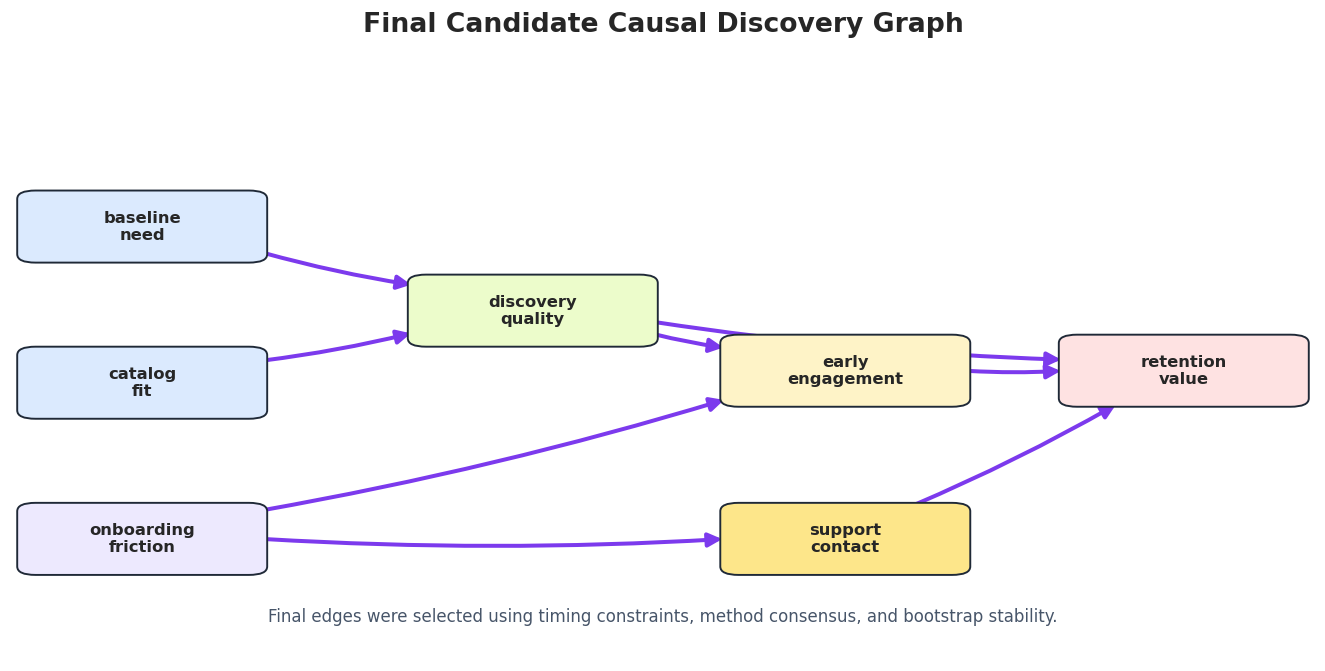

In [26]:
final_draw_edges = final_edge_table[["run", "source", "edge_type", "target"]].copy()
highlight_edges = set(zip(final_draw_edges["source"], final_draw_edges["target"]))
draw_box_graph(
    final_draw_edges,
    "Final Candidate Causal Discovery Graph",
    FIGURE_DIR / f"{NOTEBOOK_PREFIX}_final_candidate_graph.png",
    note="Final edges were selected using timing constraints, method consensus, and bootstrap stability.",
    highlight_edges=highlight_edges,
)


The final graph should be treated as a candidate structure for follow-up validation.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




### Final Graph Score Against Synthetic Truth

Because the lesson is synthetic, we can score the final graph against the known truth. This is a teaching luxury rather than something available in real case studies.


In [27]:
final_metrics = summarize_against_truth(final_draw_edges, "final_candidate", scenario="case_study_final")
final_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_final_candidate_metrics.csv", index=False)
display(final_metrics.round(4))


,scenario,method,reported_edges,skeleton_precision,skeleton_recall,skeleton_f1,directed_precision,directed_recall,directed_f1,extra_adjacencies,missed_adjacencies,reversed_true_edges,missed_adjacency_list,extra_adjacency_list
0,case_study_final,final_candidate,8,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,,


The final score quantifies how well the workflow recovered the synthetic truth. In real work, the equivalent review would be expert plausibility, stability, and validation against interventions or future data.





## Reporting and Takeaways

### Report-Ready Edge Summary

The next table turns the final graph into a compact report output. It labels each edge by evidence strength and notes the likely role in the funnel.


In [28]:
# Define reusable helpers for the Report-Ready Edge Summary section.
def evidence_label(row):
    """
    Idea: Compute the evidence label needed in the Report-Ready Edge Summary section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    row : object
        Single result row being formatted or converted.
    
    Returns
    -------
    str
        Readable text representation produced by evidence label.
    """
    if row["lingam_rate"] >= 0.90 and row["methods_with_any_support"] >= 2:
        return "strong candidate"
    if row["overall_inclusion_rate"] >= 0.30:
        return "moderate candidate"
    return "review only"
edge_role_lookup = {
    ("baseline_need", "discovery_quality"): "upstream need to discovery mechanism",
    ("catalog_fit", "discovery_quality"): "catalog fit to discovery mechanism",
    ("onboarding_friction", "early_engagement"): "friction reducing early engagement",
    ("onboarding_friction", "support_contact"): "friction increasing support burden",
    ("discovery_quality", "early_engagement"): "discovery driving early usage",
    ("discovery_quality", "retention_value"): "direct discovery-to-retention path",
    ("early_engagement", "retention_value"): "engagement-to-retention path",
    ("support_contact", "retention_value"): "support burden to retention path",
}
report_edge_summary = final_edge_table.copy()
report_edge_summary["evidence_label"] = report_edge_summary.apply(evidence_label, axis=1)
report_edge_summary["business_role"] = report_edge_summary.apply(lambda row: edge_role_lookup.get((row["source"], row["target"]), "requires review"), axis=1)
report_edge_summary = report_edge_summary[
    [
        "source",
        "target",
        "evidence_label",
        "business_role",
        "overall_inclusion_rate",
        "pc_rate",
        "ges_rate",
        "lingam_rate",
        "methods_with_any_support",
    ]
]
report_edge_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_report_edge_summary.csv", index=False)
display(report_edge_summary.round(3))


,source,target,evidence_label,business_role,overall_inclusion_rate,pc_rate,ges_rate,lingam_rate,methods_with_any_support
0,baseline_need,discovery_quality,strong candidate,upstream need to discovery mechanism,0.983,1.00,0.95,1.0,3
1,catalog_fit,discovery_quality,strong candidate,catalog fit to discovery mechanism,0.983,1.00,0.95,1.0,3
2,discovery_quality,early_engagement,strong candidate,discovery driving early usage,1.000,1.00,1.00,1.0,3
3,discovery_quality,retention_value,strong candidate,direct discovery-to-retention path,0.750,0.25,1.00,1.0,3
4,early_engagement,retention_value,strong candidate,engagement-to-retention path,1.000,1.00,1.00,1.0,3
5,onboarding_friction,early_engagement,strong candidate,friction reducing early engagement,0.867,0.60,1.00,1.0,3
6,onboarding_friction,support_contact,strong candidate,friction increasing support burden,0.750,1.00,0.25,1.0,3
7,support_contact,retention_value,strong candidate,support burden to retention path,1.000,1.00,1.00,1.0,3


This table is the sort of output that can move into a written report. It gives the edge, the evidence level, and a plain-language role.


### Case-Study Limitations

A complete discovery case study includes limitations directly beside the result. The code below creates a concise limitations table.


| limitation | practical_response |
| --- | --- |
| Observational graph discovery is not causal proof | Use the final graph to prioritize experiments, natural experiments, or effect estimation. |
| Hidden confounding can create misleading adjacencies | Use FCI diagnostics, sensitivity checks, richer covariates, or study designs that address omitted causes. |
| Timing constraints are domain assumptions | Document why each tier is plausible and revisit tiers when measurement timing changes. |
| LiNGAM depends on linear non-Gaussian assumptions | Check residuals, compare with nonparametric methods, and avoid overclaiming directions from one method. |
| Bootstrap row resampling is a simple stability check | For temporal or clustered data, use block, user-level, or time-split stability checks instead. |
| Synthetic truth is available only in this tutorial | In real applications, replace truth scoring with domain review and validation on new data or interventions. |


The limitations are not an apology for the analysis. They are part of the analysis. Causal discovery is most useful when its uncertainty is visible.


### Final Workflow Checklist

The checklist below summarizes the end-to-end workflow in reusable form.


| step | completed_here | evidence |
| --- | --- | --- |
| Define graph target | True | case-study question and true example graph |
| Create variable dictionary | True | 16_variable_dictionary.csv |
| Audit data quality | True | 16_data_audit.csv and diagnostic figures |
| Encode domain constraints | True | 16_timing_constraints.csv |
| Run candidate algorithms | True | 16_candidate_method_edges.csv |
| Compare graph layers | True | 16_candidate_method_metrics.csv |
| Check tuning sensitivity | True | 16_tuning_sensitivity.csv |
| Check bootstrap stability | True | 16_edge_stability.csv |
| Screen hidden-confounding risk | True | 16_fci_edges.csv and hidden stress table |
| Report final candidate graph | True | 16_final_candidate_edges.csv |


This checklist is the reusable template. Future case studies can swap in real data while keeping the same analysis structure.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


## Summary


The case study closes by emphasizing the workflow. A credible causal-discovery analysis defines the question, audits the data, applies defensible constraints, estimates candidate graphs, stress-tests the result, selects a graph cautiously, and reports the remaining uncertainty clearly.
